In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Telco.csv')

In [4]:
pd.set_option('display.max_columns' , None) # used for displaying max columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Getting Basic info of the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df["TotalCharges"].dtype)

# Show values that cannot be converted
mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(df.loc[mask, "TotalCharges"])

object
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [8]:
df.drop(index=[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], inplace=True)

In [9]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [10]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0:'No' , 1 : 'Yes'})

In [14]:
df['MonthlySpentCategory']=1

In [18]:
def mc(x):
    if x<40:
        return 'Low'
    elif x<70 :
        return 'Medium'
    elif x<90:
        return 'High'
    else :
        return 'Very High'

In [19]:
df['MonthlySpentCategory']=df['MonthlyCharges'].apply(mc)

In [20]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlySpentCategory
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,High
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Very High
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Low
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,High


In [21]:
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 24:
        return "Short-term"
    elif x <= 48:
        return "Mid-term"
    elif x <= 60:
        return "Long-term"
    else:
        return "Loyal"

In [22]:
df['TenureGroup']=df['tenure'].apply(tenure_group) #No loop required here.

In [28]:
df["AvgCharge"] = df["TotalCharges"]/(df["tenure"])

In [29]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlySpentCategory,TenureGroup,AvgCharge
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low,New,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium,Mid-term,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium,New,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium,Mid-term,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High,New,75.825000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,High,Short-term,82.937500
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Very High,Loyal,102.262500
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Low,New,31.495455
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,High,New,76.650000


# Business Related Questions

# Churned Percentage

In [32]:
group1=df.groupby('Churn').size().reset_index()
group1

,Churn,0
0,No,5163
1,Yes,1869


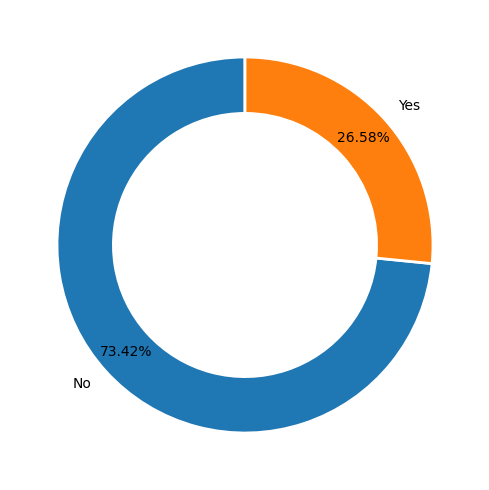

In [36]:
plt.figure(figsize=(7,5))


labels = ['No' , 'Yes']
plt.pie(group1[0],labels=labels,autopct='%1.2f%%' , startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})


plt.tight_layout()
plt.show()

# Distribution Of Customer By Gender

In [37]:
group2=df.groupby('gender').size().reset_index()
group2

,gender,0
0,Female,3483
1,Male,3549


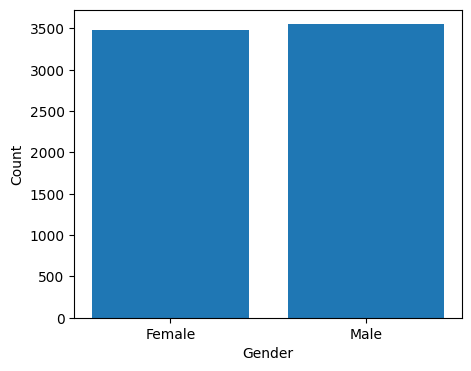

In [61]:

plt.figure(figsize=(5,4))
plt.bar(group2['gender'] , group2[0] )

plt.xlabel('Gender')
plt.ylabel('Count')


plt.show()

# Churn Between Male and Female 

In [42]:
group3=df.groupby(['gender' , 'Churn']).size().reset_index()
group3

,gender,Churn,0
0,Female,No,2544
1,Female,Yes,939
2,Male,No,2619
3,Male,Yes,930


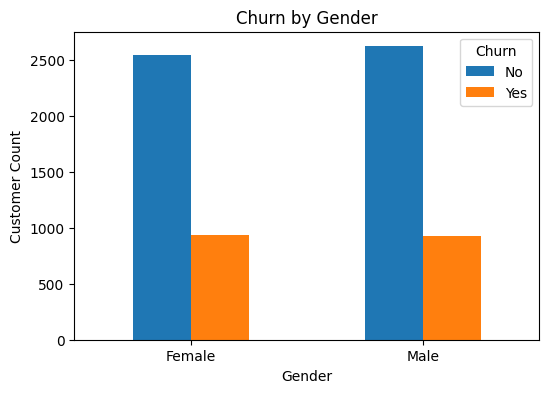

In [44]:


pivot = group3.pivot(index='gender', columns='Churn', values=0)

pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Churn by Contract Type

In [69]:
group5=df.groupby(['Contract' , 'Churn']).size().reset_index(name='Count')

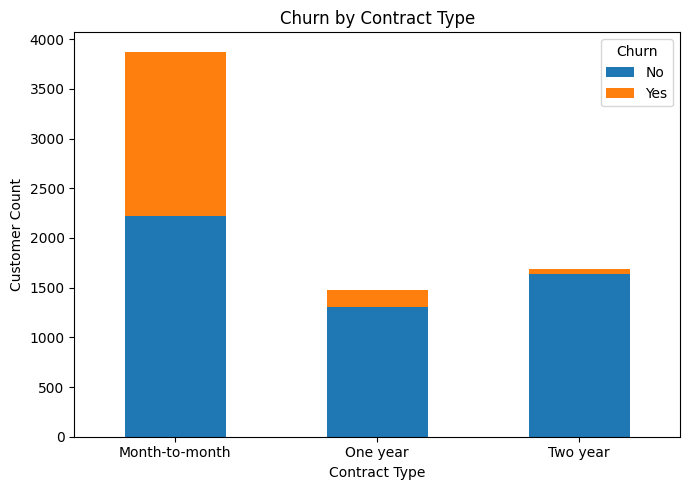

In [70]:

pivot = group5.pivot(index='Contract', columns='Churn', values='Count')

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# How does churn vary across tenure groups?

In [72]:
group4=df.groupby(['TenureGroup' , 'Churn']).size().reset_index(name='Count')

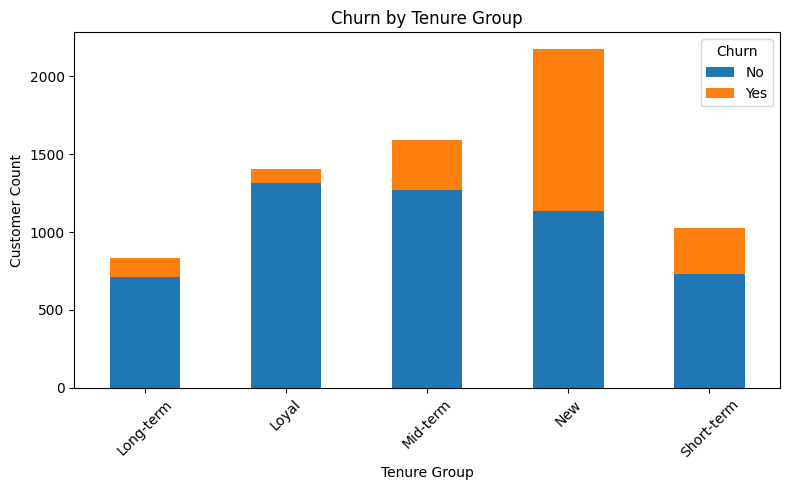

In [73]:



pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# Are senior citizens more likely to churn?

In [74]:
group6=df.groupby(['SeniorCitizen' , 'Churn']).size().reset_index(name='Count')

In [75]:
group6

,SeniorCitizen,Churn,Count
0,No,No,4497
1,No,Yes,1393
2,Yes,No,666
3,Yes,Yes,476


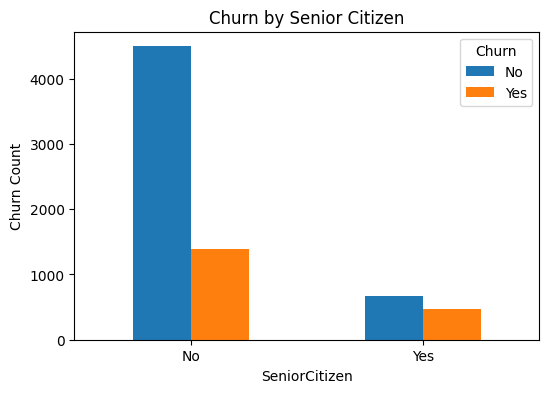

In [78]:
pivot = group6.pivot(index='SeniorCitizen', columns='Churn', values='Count')
pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Senior Citizen")
plt.xlabel("SeniorCitizen")
plt.ylabel('Churn Count')

plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Do customers with partners churn less?

In [79]:
group7=df.groupby(['Partner' , 'Churn']).size().reset_index(name='Count')

In [84]:
group7

,Partner,Churn,Count
0,No-Partner,No,2439
1,No-Partner,Yes,1200
2,Have a Partner,No,2724
3,Have a Partner,Yes,669


In [82]:
group7['Partner']=group7['Partner'].map({'No' : 'No-Partner' , 'Yes' : 'Have a Partner' })

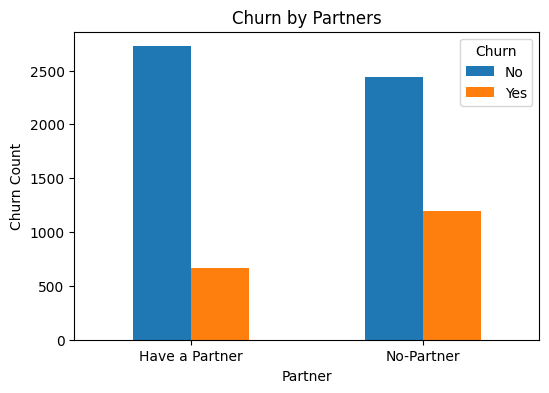

In [83]:
pivot = group7.pivot(index='Partner', columns='Churn', values='Count')
pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Partners")
plt.xlabel("Partner")
plt.ylabel('Churn Count')

plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()